In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [2]:
df = pd.read_csv("data/cleaned_customers.csv")

df.head()

,Customer ID,Age,Gender,Marital Status,Education Level,Geographic Information,Occupation,Income Level,Behavioral Data,Purchase History,...,Premium Amount,Policy Type,Customer Preferences,Preferred Communication Channel,Preferred Contact Time,Preferred Language,Segmentation Group,Age_Group,Income_Level,Spending_Category
0,84966,23,0,Married,Associate Degree,Mizoram,Entrepreneur,70541,policy5,04-10-2018,...,2749,Group,Email,In-Person Meeting,Afternoon,English,Segment5,Young,Medium,Medium
1,95568,26,1,Widowed,Doctorate,Goa,Manager,54168,policy5,11-06-2018,...,1966,Group,Mail,In-Person Meeting,Morning,French,Segment5,Adult,Medium,High
2,10544,29,0,Single,Associate Degree,Rajasthan,Entrepreneur,73899,policy5,06-05-2021,...,4413,Group,Email,Mail,Evening,German,Segment3,Adult,Medium,High
3,77033,20,1,Divorced,Bachelor's Degree,Sikkim,Entrepreneur,63381,policy5,09-02-2018,...,4342,Family,Text,In-Person Meeting,Anytime,French,Segment3,Young,Medium,High
4,88160,25,0,Separated,Bachelor's Degree,West Bengal,Manager,38794,policy1,09-10-2018,...,1276,Family,Email,Text,Weekends,English,Segment2,Young,Low,Medium


In [3]:
print(df.shape)

(53503, 23)


In [4]:
X = df.drop(
    columns=["Customer ID"],
    errors="ignore"
)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53503 entries, 0 to 53502
Data columns (total 23 columns):
 #   Column                              Non-Null Count  Dtype 
---  ------                              --------------  ----- 
 0   Customer ID                         53503 non-null  int64 
 1   Age                                 53503 non-null  int64 
 2   Gender                              53503 non-null  int64 
 3   Marital Status                      53503 non-null  object
 4   Education Level                     53503 non-null  object
 5   Geographic Information              53503 non-null  object
 6   Occupation                          53503 non-null  object
 7   Income Level                        53503 non-null  int64 
 8   Behavioral Data                     53503 non-null  object
 9   Purchase History                    53503 non-null  object
 10  Interactions with Customer Service  53503 non-null  object
 11  Insurance Products Owned            53503 non-null  ob

In [7]:
features = [
    "Age",
    "Income Level",
    "Coverage Amount",
    "Premium Amount"
]

X = df[features]

X.head()

,Age,Income Level,Coverage Amount,Premium Amount
0,23,70541,366603,2749
1,26,54168,780236,1966
2,29,73899,773926,4413
3,20,63381,787815,4342
4,25,38794,366506,1276


In [8]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Scaled Shape:", X_scaled.shape)

Scaled Shape: (53503, 4)


In [15]:
import pickle

with open(
    "models/scaler.pkl",
    "wb"
) as file:

    pickle.dump(
        scaler,
        file
    )

print("Scaler Saved Successfully")

Scaler Saved Successfully


In [17]:
pca_full = PCA()

pca_full.fit(X_scaled)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",None
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized S

In [18]:
explained_variance = pca_full.explained_variance_ratio_

variance_df = pd.DataFrame({
    "Component": range(
        1,
        len(explained_variance)+1
    ),
    "Variance": explained_variance
})

variance_df

,Component,Variance
0,1,0.255161
1,2,0.250825
2,3,0.248603
3,4,0.245412


In [19]:
cumulative_variance = np.cumsum(
    explained_variance
)

cumulative_variance

array([0.25516067, 0.50598522, 0.75458786, 1.        ])

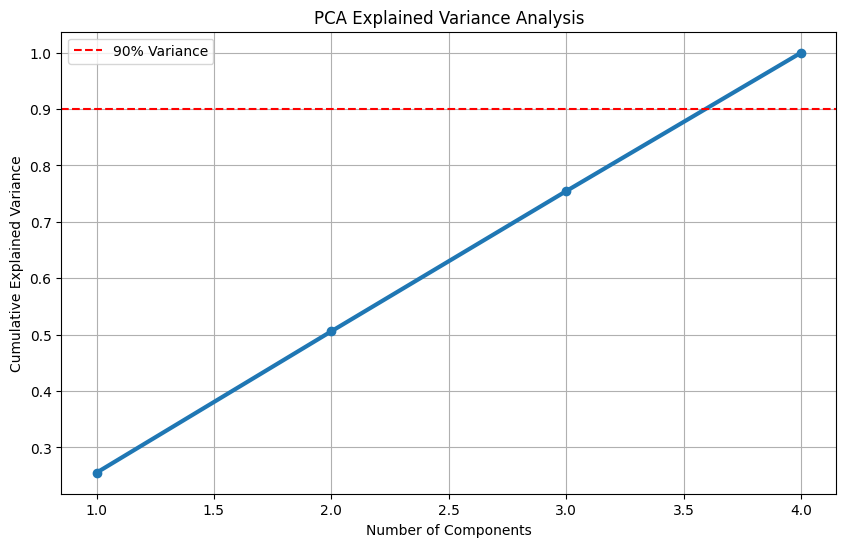

In [20]:
plt.figure(figsize=(10,6))

plt.plot(
    range(
        1,
        len(cumulative_variance)+1
    ),
    cumulative_variance,
    marker="o",
    linewidth=3
)

plt.axhline(
    y=0.90,
    color="red",
    linestyle="--",
    label="90% Variance"
)

plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")

plt.title(
    "PCA Explained Variance Analysis"
)

plt.legend()

plt.grid(True)

plt.show()

In [21]:
pca = PCA(
    n_components=2
)

X_pca = pca.fit_transform(
    X_scaled
)

print("PCA Shape:", X_pca.shape)

PCA Shape: (53503, 2)


In [22]:
pca_df = pd.DataFrame(
    X_pca,
    columns=[
        "PC1",
        "PC2"
    ]
)

pca_df.head()

,PC1,PC2
0,-0.538448,-1.028938
1,0.905685,-1.545452
2,0.483869,0.156733
3,0.518788,-0.290229
4,0.141564,-1.989868


In [23]:
variance_retained = (
    pca.explained_variance_ratio_.sum()
    * 100
)

print(
    f"Variance Retained: {variance_retained:.2f}%"
)

Variance Retained: 50.60%


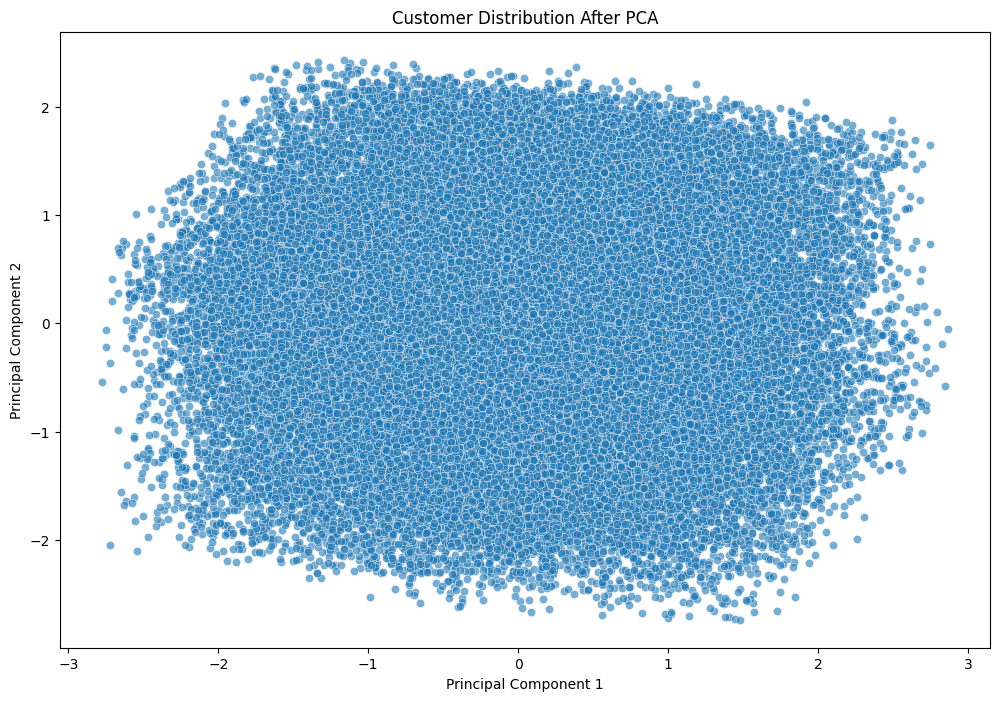

In [24]:
plt.figure(figsize=(12,8))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    alpha=0.6
)

plt.title(
    "Customer Distribution After PCA"
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()

In [25]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[
        "PC1",
        "PC2"
    ],
    index=features
)

loadings

,PC1,PC2
Age,0.321086,0.594199
Income Level,-0.654717,0.160557
Coverage Amount,0.681510,-0.054655
Premium Amount,-0.061587,0.786233


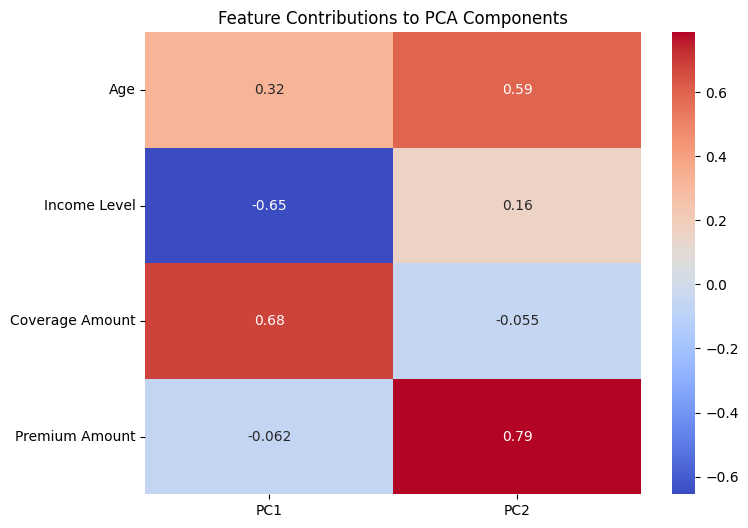

In [26]:
plt.figure(figsize=(8,6))

sns.heatmap(
    loadings,
    annot=True,
    cmap="coolwarm"
)

plt.title(
    "Feature Contributions to PCA Components"
)

plt.show()

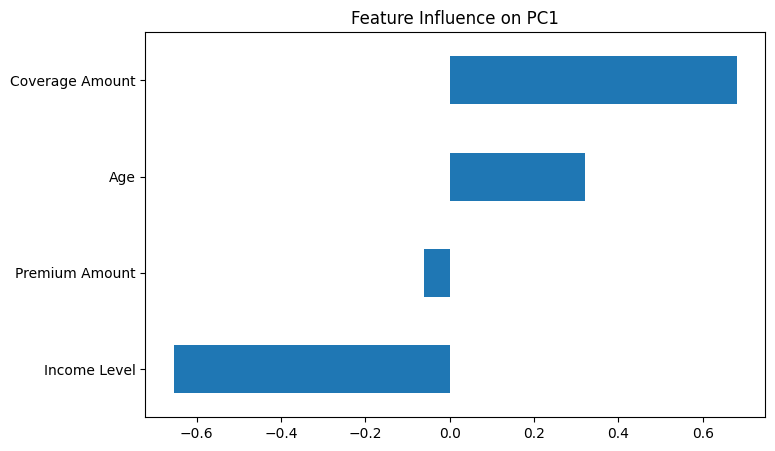

In [27]:
plt.figure(figsize=(8,5))

loadings["PC1"].sort_values().plot(
    kind="barh"
)

plt.title(
    "Feature Influence on PC1"
)

plt.show()

In [29]:
pca_df.to_csv(
    "data/pca_data.csv",
    index=False
)

print("PCA Dataset Saved")

PCA Dataset Saved


In [30]:
with open(
    "models/pca.pkl",
    "wb"
) as file:

    pickle.dump(
        pca,
        file
    )

print("PCA Model Saved")

PCA Model Saved


In [31]:
import os

print("Models Folder:")
print(os.listdir("models"))

print("\n Data Folder:")
print(os.listdir("data"))

Models Folder:
['pca.pkl', 'scaler.pkl']

 Data Folder:
['cleaned_customers.csv', 'customer_segmentation.csv', 'pca_data.csv']


In [33]:
#PCA ANALYSIS INSIGHTS

#1. PCA reduced customer information into two principal dimensions.

#2. The majority of customer variation is explained by:
    #Income Level
    #Coverage Amount
    #Premium Amount
    #Age

#3. PCA simplifies customer visualization.

#4. Reduced dimensions improve clustering performance.

#5. PCA prepares the dataset for K-Means, Hierarchical Clustering and DBSCAN.